In [1]:
import os
import numpy as np
import xarray as xr
import glob
import pandas as pd
import re
import matplotlib.pyplot as plt
import json

In [2]:
#读取feedback and forcing data
f = open('/data04/shiy/code_cloud/feedback_cmip6/zk_cmip56/cmip56_forcing_feedback_ecs-master/cmip56_forcing_feedback_ecs.json','r')
data = json.load(f)

In [3]:
models=['ACCESS-CM2','ACCESS-ESM1-5','BCC-CSM2-MR','CanESM5','CAS-ESM2-0','CESM2-WACCM','CMCC-CM2-SR5','EC-Earth3-CC','FGOALS-g3','GFDL-ESM4','INM-CM4-8','INM-CM5-0','IPSL-CM6A-LR','KACE-1-0-G','KIOST-ESM','MIROC6','MPI-ESM1-2-HR','MPI-ESM1-2-LR','MRI-ESM2-0','NESM3']
#20个模式
ECS=np.zeros(len(models))
CF=np.zeros(len(models))
for m in range(len(models)):
    if models[m]=='CAS-ESM2-0':
        ECS[m]=3.45
        CF[m]=0.47
    elif models[m]=='KIOST-ESM':
        ECS[m]=3.36
        CF[m]=0
    else:
        ECS[m]=data['CMIP6'][models[m]]['r1i1p1f1']['ECS']
        CF[m]=data['CMIP6'][models[m]]['r1i1p1f1']['CLD']
len(models)

20

In [4]:
#某变量的rank score与cloud feedback是否具有相关性
csri_rank=xr.open_dataarray('./csr_svi_rank_score_21x25.nc')

In [19]:
avg_rank=np.mean(csri_rank[:,[3,4,8,9,13,14,18,19]],1)
# index=np.argsort(avg_rank)
# avg_rerank=avg_rank.copy()
# avg_rerank[index]=np.arange(1,22)

In [6]:
avg_rerank=np.zeros(20)
for m,mo in enumerate(models):
    avg_rerank[m]=avg_rank.loc[mo]
rerank=np.zeros(20)
rerank[np.argsort(avg_rerank)]=np.arange(1,21)#####变为1-20

In [7]:
cf_re=np.zeros(20)
cf_re=CF[np.argsort(avg_rerank)]###按横坐标为1-20的cf

In [8]:
np.corrcoef(np.arange(1,21),cf_re)

array([[1.        , 0.56968294],
       [0.56968294, 1.        ]])

In [9]:
np.corrcoef(rerank,CF)

array([[1.        , 0.56968294],
       [0.56968294, 1.        ]])

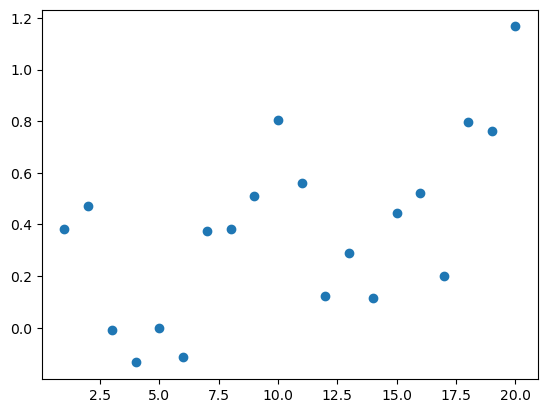

In [10]:
plt.scatter(np.arange(1,21),cf_re)

In [13]:
from scipy import stats

In [26]:
# 计算置信区间
def confidence_interval(x, y_pred, x_new):
    n = len(x)
    x_mean = np.mean(x)
    # 计算预测标准误差
    sum_sq = np.sum((y - (slope * x + intercept)) ** 2)
    std_err = np.sqrt(sum_sq / (n-2))
    # 计算置信区间
    x_new_mean = np.mean(x_new)
    std_interval = std_err * np.sqrt(1/n + (x_new - x_new_mean)**2 / 
                                   np.sum((x - x_mean)**2))
    return y_pred, y_pred - 1.96*std_interval, y_pred + 1.96*std_interval

In [32]:
# 计算回归线
slope, intercept, r_value, p_value, std_err = stats.linregress( avg_rank[0:20],ECS)
# 创建预测值
x = np.linspace(avg_rank.min(), avg_rank.max(),20)
y = slope * x + intercept
# 添加置信区间
_, lower, upper = confidence_interval(avg_rank[0:20].values, y, x)

In [34]:
# 计算回归线
slope2, intercept2, r_value2, p_value2, std_err2 = stats.linregress( avg_rank[0:20],CF)
# 创建预测值
x2 = np.linspace(avg_rank.min(), avg_rank.max(),20)
y2 = slope2 * x2 + intercept2
# 添加置信区间
_, lower2, upper2 = confidence_interval(avg_rank[0:20].values, y2, x2)

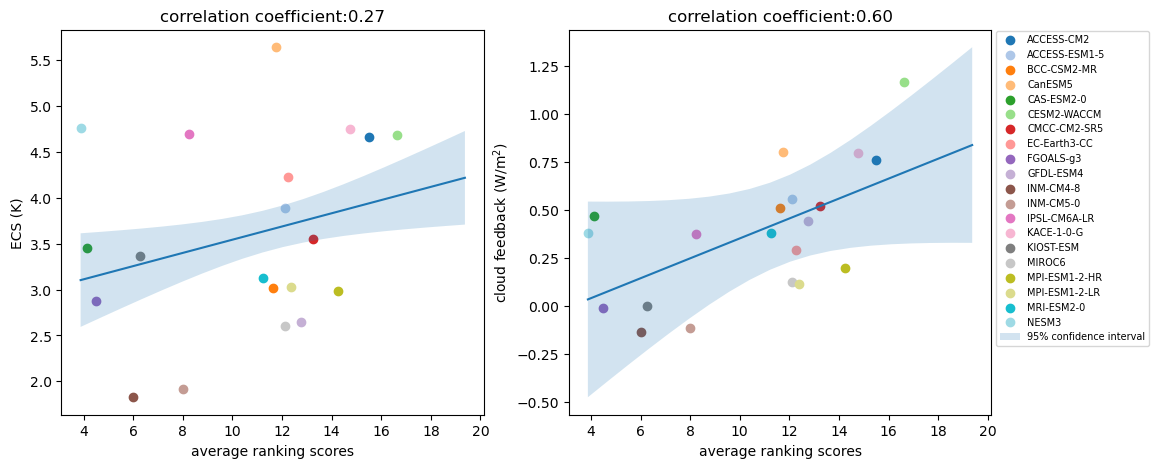

In [37]:
colors=plt.cm.tab20(np.linspace(0,1,20))
fig,ax=plt.subplots(1,2,figsize=(12,5))
for m,mo in enumerate(models):
    ax[0].scatter(avg_rank.loc[mo],ECS[m],color=colors[m])
    ax[1].scatter(avg_rank.loc[mo],CF[m],color=colors[m],label=models[m])
ax[0].plot(x, y, '-')
ax[1].plot(x2, y2, '-')
ax[0].fill_between(x, lower,upper, alpha=0.2,label='95% confidence interval')
ax[1].fill_between(x2, lower2,upper2, alpha=0.2,label='95% confidence interval')
ax[0].set_xlabel('average ranking scores')
ax[1].set_xlabel('average ranking scores')
ax[0].set_ylabel('ECS (K)')
ax[1].set_ylabel('cloud feedback (W/m$^{2}$)')
ax[0].set_title(f'correlation coefficient:{np.corrcoef(avg_rerank,ECS)[0,1]:.2f}')
ax[1].set_title(f'correlation coefficient:{np.corrcoef(avg_rerank,CF)[0,1]:.2f}')
ax[1].legend(bbox_to_anchor=(1,1.01),fontsize=7)

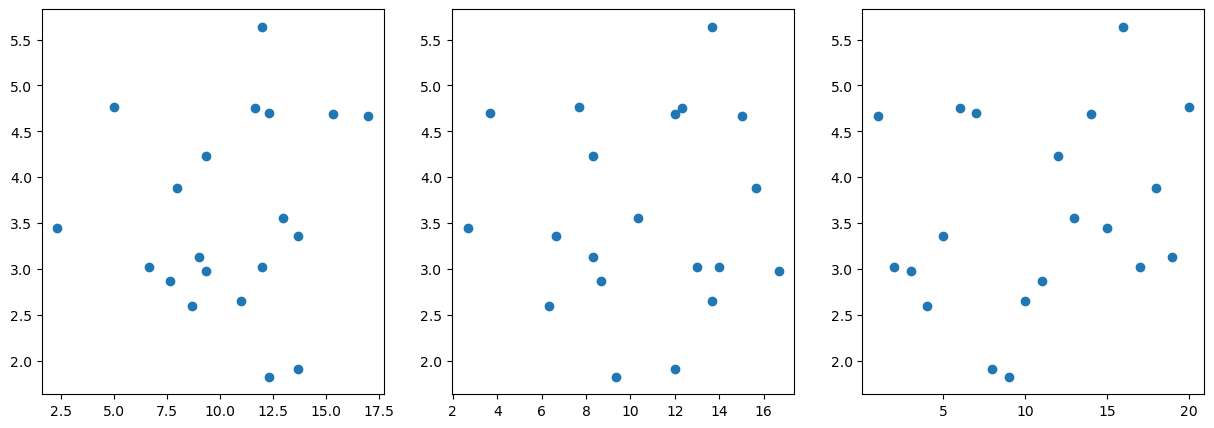

In [23]:
fig,ax=plt.subplots(1,3,figsize=(15,5))
ax[0].scatter(np.mean(csr_rank1[:,:],1),ECS)
ax[1].scatter(np.mean(csr_rank2[:,:],1),ECS)
ax[2].scatter(np.mean(csr_rank3[:,:],1),ECS)

In [2]:
data_out3=np.load('/data04/shiy/code_cloud/code_paper_7.13/fig7_3.npy')#5areax5varx1020timex24models
data_out1=np.load('/data04/shiy/code_cloud/code_paper_7.13/fig7_1.npy')#5areax5varx1980timex24models
data_out2=np.load('/data04/shiy/code_cloud/code_paper_7.13/fig7_2.npy')
data_out=np.concatenate((data_out1,data_out2),axis = 2)
data_outt=np.concatenate((data_out1,data_out3),axis = 2)
areanum=np.arange(5)
varnum=np.arange(5)
time=pd.date_range('18500101','20991231',freq='M')
gwnum=np.arange(6)
modelnum=np.arange(23)
data2xr=xr.DataArray(data_out[:,:,:,:], coords=[areanum,varnum, time,modelnum], dims=['areanum','varnum', 'time','modelnum'])
data22xr=xr.DataArray(data_outt[:,:,:,:], coords=[areanum,varnum, time,modelnum], dims=['areanum','varnum', 'time','modelnum'])
datay2=data2xr.loc[:,:,'1850-01-01':'2099-12-31',:].groupby('time.year').mean()#.values#变成年平均
datay22=data22xr.loc[:,:,'1850-01-01':'2099-12-31',:].groupby('time.year').mean()#.values#变成年平均

In [16]:
#read in tas
models=['ACCESS-CM2','ACCESS-ESM1-5','AWI-CM-1-1-MR','BCC-CSM2-MR','CanESM5','CAS-ESM2-0','CESM2-WACCM','CIESM','CMCC-CM2-SR5','EC-Earth3-CC','FGOALS-f3-L','FGOALS-g3','GFDL-ESM4','INM-CM4-8','INM-CM5-0','IPSL-CM6A-LR','KACE-1-0-G','KIOST-ESM','MIROC6','MPI-ESM1-2-HR','MPI-ESM1-2-LR','MRI-ESM2-0','NESM3']
model_his='/data04/shiy/cmip6_his_ssp585/historical/'
#先取出cas的历史实验各个变量并求areamean
print('cas-esm2')
tas_his=np.zeros([165,23])
cas_his='/data03/cmip6/post-new/CMIP6/CMIP6/CMIP/CAS/CAS-ESM2-0/historical/r1i1p1f1/Amon/tas/'
cas_path=cas_his+os.listdir(cas_his)[0]+'/'
cas_path=cas_path+os.listdir(cas_path)[0]+'/'
cas_path=cas_path+os.listdir(cas_path)[0]
tas=xr.open_dataset(cas_path)['tas'].loc['1850-01-01':'2014-12-30',-90:90,0:360]
weights=np.cos(np.deg2rad(tas.coords['lat']))
tas_weighted_mean=tas.weighted(weights).mean(('lon','lat')).groupby('time.year').mean()
tas_his[:,5]=tas_weighted_mean
for m in range(len(models)):
    if m!=5:
        print(models[m])
        #求swcrf
        fhis=glob.glob(model_his+models[m]+'/tas_Amon_'+models[m]+'_historical_r1i1p1f1'+'*185001-201412.nc')[0]
        tas=xr.open_dataset(fhis)['tas'].loc['1850-01-01':'2014-12-30',-90:90,0:360] #240x48x192
        weights=np.cos(np.deg2rad(tas.coords['lat']))
        weights.name='weights'
        tas_weighted_mean=tas.weighted(weights).mean(('lon','lat')).groupby('time.year').mean()
        tas_his[:,m]=tas_weighted_mean

cas-esm2
ACCESS-CM2
ACCESS-ESM1-5
AWI-CM-1-1-MR
BCC-CSM2-MR
CanESM5
CESM2-WACCM


/data04/shiy/anaconda3/envs/climlib/lib/python3.8/site-packages/xarray/conventions.py:551: SerializationWarning: variable 'tas' has multiple fill values {1e+20, 1e+20}, decoding all values to NaN.
  new_vars[k] = decode_cf_variable(


CIESM
CMCC-CM2-SR5
EC-Earth3-CC
FGOALS-f3-L
FGOALS-g3
GFDL-ESM4
INM-CM4-8
INM-CM5-0
IPSL-CM6A-LR
KACE-1-0-G
KIOST-ESM
MIROC6
MPI-ESM1-2-HR
MPI-ESM1-2-LR
MRI-ESM2-0
NESM3


In [14]:
model_his='/data04/shiy/cmip6_his_ssp585/ssp245/'
#先取出cas的历史实验各个变量并求areamean
# print('cas-esm2')
tas_ssp245=np.zeros([85,23])
cas_his='/data03/cmip6/post-new/CMIP6/CMIP6/ScenarioMIP/CAS/CAS-ESM2-0/ssp245/r1i1p1f1/Amon/tas/'
cas_path=cas_his+os.listdir(cas_his)[0]+'/'
cas_path=cas_path+os.listdir(cas_path)[0]+'/'
cas_path=cas_path+os.listdir(cas_path)[0]
tas=xr.open_dataset(cas_path)['tas'].loc['2015-01-01':'2099-12-31',-90:90,0:360]
weights=np.cos(np.deg2rad(tas.coords['lat']))
tas_weighted_mean=tas.weighted(weights).mean(('lon','lat')).groupby('time.year').mean()
tas_ssp245[:,5]=tas_weighted_mean
for m in range(len(models)):
    if m!=5:
#         print(models[m])
        fhis=glob.glob(model_his+models[m]+'/tas_Amon_'+models[m]+'_ssp245_r1i1p1f1'+'*201501-210012.nc')[0]
        fhis_data=xr.open_dataset(fhis)['tas']
        if len(fhis_data['time'])==1032:
            fhis_data['time']=pd.date_range('20150101','21001231',freq='M')
        tas=fhis_data.loc['2015-01-01':'2099-12-31',-90:90,0:360] #240x48x192
        weights=np.cos(np.deg2rad(tas.coords['lat']))
        weights.name='weights'
        tas_weighted_mean=tas.weighted(weights).mean(('lon','lat')).groupby('time.year').mean()
        tas_ssp245[:,m]=tas_weighted_mean

In [15]:
model_his='/data04/shiy/cmip6_his_ssp585/ssp585/'
# print('cas-esm2')
tas_ssp585=np.zeros([85,23])
cas_his='/data03/cmip6/post-new/CMIP6/CMIP6/ScenarioMIP/CAS/CAS-ESM2-0/ssp585/r1i1p1f1/Amon/tas/'
cas_path=cas_his+os.listdir(cas_his)[0]+'/'
cas_path=cas_path+os.listdir(cas_path)[0]+'/'
cas_path=cas_path+os.listdir(cas_path)[0]
tas=xr.open_dataset(cas_path)['tas'].loc['2015-01-01':'2099-12-31',-90:90,0:360]
weights=np.cos(np.deg2rad(tas.coords['lat']))
tas_weighted_mean=tas.weighted(weights).mean(('lon','lat')).groupby('time.year').mean()
tas_ssp585[:,5]=tas_weighted_mean
for m in range(len(models)):
    if m!=5:
#         print(models[m])
        fhis=glob.glob(model_his+models[m]+'/tas_Amon_'+models[m]+'_ssp585_r1i1p1f1'+'*201501-210012.nc')[0]
        fhis_data=xr.open_dataset(fhis)['tas']
        if len(fhis_data['time'])==1032:
            fhis_data['time']=pd.date_range('20150101','21001231',freq='M')
        tas=fhis_data.loc['2015-01-01':'2099-12-31',-90:90,0:360] #240x48x192
        weights=np.cos(np.deg2rad(tas.coords['lat']))
        weights.name='weights'
        tas_weighted_mean=tas.weighted(weights).mean(('lon','lat')).groupby('time.year').mean()
        tas_ssp585[:,m]=tas_weighted_mean

/data04/shiy/anaconda3/envs/climlib/lib/python3.8/site-packages/xarray/conventions.py:551: SerializationWarning: variable 'tas' has multiple fill values {1e+20, 1e+20}, decoding all values to NaN.
  new_vars[k] = decode_cf_variable(


In [23]:
datay2.loc[0,0,'2014-12-31':'2099-12-31',:]

<xarray.DataArray (year: 85, modelnum: 23)>
array([[-44.23791722, -42.20823649, -44.3361364 , ..., -47.81006847,
        -44.12206447, -49.27083267],
       [-44.15392535, -41.96809867, -44.47869519, ..., -48.03419065,
        -44.09404532, -49.43019122],
       [-44.06636476, -41.92839276, -45.10613884, ..., -48.04390293,
        -44.72802951, -49.34118788],
       ...,
       [-41.26992713, -40.76148533, -45.21395255, ..., -48.82132388,
        -43.01849297, -49.25002092],
       [-41.171073  , -40.66153116, -45.10144909, ..., -48.14663416,
        -43.03313162, -49.55626345],
       [-41.46376256, -40.41527154, -44.76695695, ..., -48.04180192,
        -43.10627661, -49.19245924]])
Coordinates:
    areanum   int64 0
    varnum    int64 0
  * modelnum  (modelnum) int64 0 1 2 3 4 5 6 7 8 ... 14 15 16 17 18 19 20 21 22
  * year      (year) int64 2015 2016 2017 2018 2019 ... 2095 2096 2097 2098 2099

In [29]:
#cal cloud feeedback
cf_his=np.zeros(23)
cf_ssp245=np.zeros(23)
cf_ssp585=np.zeros(23)

ct_his=np.zeros(23)
ct_ssp245=np.zeros(23)
ct_ssp585=np.zeros(23)
for m in range(23):
    cf_his[m], intercept = np.polyfit(tas_his[:,m],datay2.loc[0,0,'1849-12-01':'2014-12-31',m]+datay2.loc[0,1,'1849-12-01':'2014-12-31',m] , 1)
    cf_ssp245[m], intercept = np.polyfit(tas_ssp245[:,m],datay2.loc[0,0,'2014-12-31':'2099-12-31',m]+datay2.loc[0,1,'2014-12-31':'2099-12-31',m] , 1)
    cf_ssp585[m], intercept = np.polyfit(tas_ssp585[:,m],datay22.loc[0,0,'2014-12-31':'2099-12-31',m]+datay22.loc[0,1,'2014-12-31':'2099-12-31',m] , 1)
    
    ct_his[m], intercept = np.polyfit(tas_his[:,m],datay2.loc[0,4,'1849-12-01':'2014-12-31',m] , 1)
    ct_ssp245[m], intercept = np.polyfit(tas_ssp245[:,m],datay2.loc[0,4,'2014-12-31':'2099-12-31',m], 1)
    ct_ssp585[m], intercept = np.polyfit(tas_ssp585[:,m],datay22.loc[0,4,'2014-12-31':'2099-12-31',m], 1)


TypeError: 'Axes' object is not subscriptable

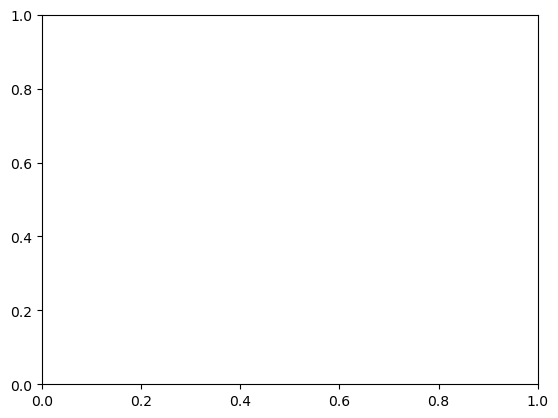

In [38]:
fig,ax=plt.subplots(1,2)
ax[0].scatter(ct_his,ct_ssp585)
ax[0].set_xlabel('historical CLT feedback(%/K)')
ax[0].set_ylabel('ssp585 CLT feedback(%/K)')

ax[1].scatter(cf_his,cf_ssp585)
ax[1].set_xlabel('historical CRF feedback(W/m^2/K)')
ax[1].set_ylabel('ssp585 CRF feedback(%/K)')
# ax[1].scatter(ct_his,ct_ssp245)
# ax[1].set_xlabel('historical CLT feedback(%/K)')
# ax[1].set_ylabel('ssp245 CLT feedback(%/K)')

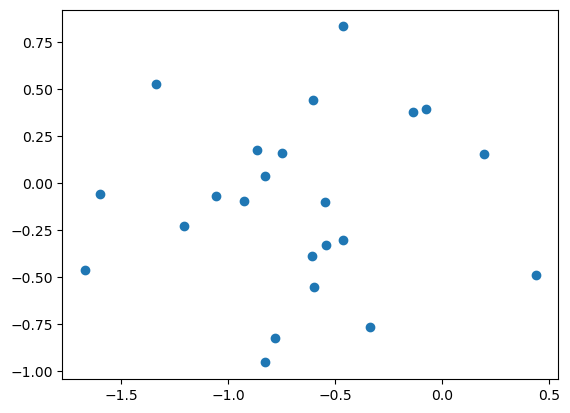

In [27]:
plt.scatter(cf_his,cf_ssp585)

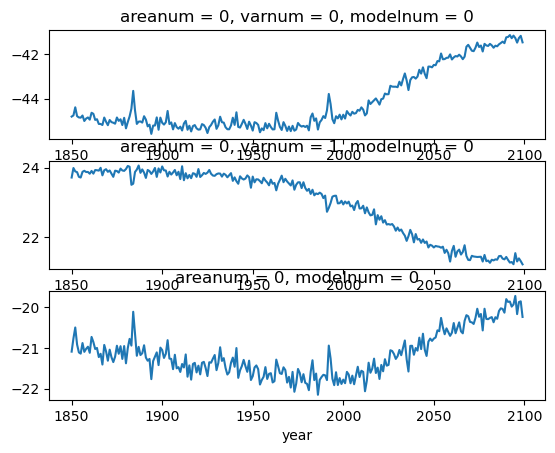

In [3]:
fig,ax=plt.subplots(3,1)
datay2[0,0,:,0].plot(ax=ax[0])
datay2[0,1,:,0].plot(ax=ax[1])
(datay2[0,0,:,0]+datay2[0,1,:,0]).plot(ax=ax[2])